In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from apyori import apriori

In [2]:
basket = pd.read_csv('./Market_Basket.csv',header=None)
basket

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
basketList = (basket.to_numpy())
basketList

array([['shrimp', 'almonds', 'avocado', ..., 'frozen smoothie',
        'spinach', 'olive oil'],
       ['burgers', 'meatballs', 'eggs', ..., nan, nan, nan],
       ['chutney', nan, nan, ..., nan, nan, nan],
       ...,
       ['chicken', nan, nan, ..., nan, nan, nan],
       ['escalope', 'green tea', nan, ..., nan, nan, nan],
       ['eggs', 'frozen smoothie', 'yogurt cake', ..., nan, nan, nan]],
      shape=(7501, 20), dtype=object)

<Axes: xlabel='None', ylabel='count'>

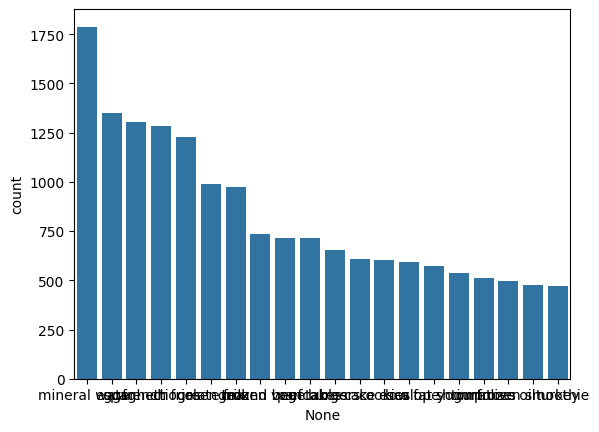

In [4]:
x2=pd.Series(basketList.flatten())
x2.dropna(inplace=True)

sns.barplot(x=x2.value_counts().head(20).index,y=x2.value_counts().head(20))

In [5]:
basketList = basketList.tolist()
for x in basketList:
    while np.nan in x:
        x.remove(np.nan)
        
basketList

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea'],
 ['low fat yogurt'],
 ['whole wheat pasta', 'french fries'],
 ['soup', 'light cream', 'shallot'],
 ['frozen vegetables', 'spaghetti', 'green tea'],
 ['french fries'],
 ['eggs', 'pet food'],
 ['cookies'],
 ['turkey', 'burgers', 'mineral water', 'eggs', 'cooking oil'],
 ['spaghetti', 'champagne', 'cookies'],
 ['mineral water', 'salmon'],
 ['mineral water'],
 ['shrimp',
  'chocolate',
  'chicken',
  'honey',
  'oil',
  'cooking oil',
  'low fat yogurt'],
 ['turkey', 'eggs'],
 ['turkey',
  'fresh tuna',
  'tomatoes',
  'spagh

In [6]:
rules1 = apriori(basketList,min_support=0.009,min_confidence=0.09)
r1 = list(rules1)

In [7]:
rules2 = apriori(basketList,min_support=0.008,min_confidence=0.02)
r2 = list(rules2)

In [8]:
frequent_items = []
supports = []
confidences = []
lifts = []

In [9]:
for r in r1:
    frequent_items.append(r.items)
    supports.append(r.support)
    confidences.append(r.ordered_statistics[0].confidence)
    lifts.append(r.ordered_statistics[0].lift)


In [11]:
rules1_df = pd.DataFrame()
rules1_df['items']=frequent_items
rules1_df['support']=supports
rules1_df['Confidence']=confidences
rules1_df['Lift']=lifts
rules1_df

,items,support,Confidence,Lift
0,(chocolate),0.163845,0.163845,1.000000
1,(eggs),0.179709,0.179709,1.000000
2,(french fries),0.170911,0.170911,1.000000
3,(frozen vegetables),0.095321,0.095321,1.000000
4,(green tea),0.132116,0.132116,1.000000
...,...,...,...,...
230,"(ground beef, mineral water, spaghetti)",0.017064,0.173677,2.907928
231,"(milk, mineral water, spaghetti)",0.015731,0.121399,2.032623
232,"(spaghetti, mineral water, olive oil)",0.010265,0.155870,2.609786
233,"(pancakes, mineral water, spaghetti)",0.011465,0.120617,2.019529


In [12]:
rules1_df.sort_values(by="Confidence")

,items,support,Confidence,Lift
57,"(chocolate, low fat yogurt)",0.014798,0.090317,1.180262
51,"(chocolate, frozen smoothie)",0.014931,0.091131,1.439102
181,"(milk, whole wheat rice)",0.011865,0.091564,1.564510
145,"(green tea, tomatoes)",0.012265,0.092836,1.357425
85,"(low fat yogurt, eggs)",0.016798,0.093472,1.221484
...,...,...,...,...
156,"(ground beef, spaghetti)",0.039195,0.398915,2.291162
33,"(mineral water, cereals)",0.010265,0.398964,1.673729
185,"(salmon, mineral water)",0.017064,0.401254,1.683336
211,"(chocolate, mineral water, eggs)",0.013465,0.405622,1.701663


In [13]:
frequent_items.clear()
supports.clear()
confidences.clear()
lifts.clear()

for r in r2:
    frequent_items.append(r.items)
    supports.append(r.support)
    confidences.append(r.ordered_statistics[0].confidence)
    lifts.append(r.ordered_statistics[0].lift)

In [14]:
rules2_df = pd.DataFrame()
rules2_df['items']=frequent_items
rules2_df['support']=supports
rules2_df['Confidence']=confidences
rules2_df['Lift']=lifts
rules2_df

,items,support,Confidence,Lift
0,(almonds),0.020397,0.020397,1.000000
1,(avocado),0.033329,0.033329,1.000000
2,(brownies),0.033729,0.033729,1.000000
3,(burgers),0.087188,0.087188,1.000000
4,(butter),0.030129,0.030129,1.000000
...,...,...,...,...
310,"(milk, mineral water, spaghetti)",0.015731,0.121399,2.032623
311,"(spaghetti, mineral water, olive oil)",0.010265,0.043065,1.878079
312,"(pancakes, mineral water, spaghetti)",0.011465,0.048098,1.908923
313,"(spaghetti, mineral water, shrimp)",0.008532,0.035794,1.688630
